# lipid_only.csv EDA
> 2024년 건강검진 데이터 | 336,389명 | 33개 변수

In [18]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.font_manager as fm
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# 한글 폰트
fm.fontManager.addfont('/System/Library/Fonts/AppleSDGothicNeo.ttc')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

DATA_PATH  = '/Users/admin/PycharmProjects/AH_03_03/ai_worker/data/lipid_only.csv'
OUTPUT_DIR = '/Users/admin/PycharmProjects/AH_03_03/etc/ml/ai_worker/ml/Clustering/outputs/eda_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CLINICAL_BOUNDS v2 (임상 근거 기반)
CLINICAL_BOUNDS = {
    '수축기혈압':         (60,  250),
    '이완기혈압':         (30,  150),
    '식전혈당(공복혈당)': (50,  500),
    '총콜레스테롤':       (50,  500),
    '트리글리세라이드':   (10,  500),
    'HDL콜레스테롤':      (10,  150),
    'LDL콜레스테롤':      (10,  400),
    '혈색소':             (5,   22),
    '혈청크레아티닌':     (0.3, 15),
    '혈청지오티(AST)':    (5,   200),
    '혈청지피티(ALT)':    (5,   200),
    '감마지티피':         (1,   300),
    '허리둘레':           (40,  160),
}

df = pd.read_csv(DATA_PATH)
print(f'shape: {df.shape}')
df.head()


shape: (336389, 33)


,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2024,3942635,27,2,16,155,60,80.0,1.0,0.8,...,6.0,16.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN
1,2024,488874,46,1,6,175,85,80.0,1.5,1.5,...,44.0,16.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2024,4002592,11,2,13,155,50,80.0,0.9,1.0,...,17.0,16.0,1.0,0.0,0,NaN,NaN,NaN,NaN,NaN
3,2024,4152459,28,1,11,170,60,78.0,1.0,0.9,...,25.0,16.0,2.0,1.0,0,NaN,NaN,NaN,NaN,NaN
4,2024,186023,31,1,6,175,70,78.0,0.8,0.8,...,10.0,16.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN


## 1. 기본 정보

In [19]:
# 컬럼 타입 및 결측치
info_df = pd.DataFrame({
    '타입': df.dtypes,
    '결측수': df.isnull().sum(),
    '결측률(%)': (df.isnull().sum() / len(df) * 100).round(2),
    '유니크수': df.nunique()
})
print(info_df.to_string())

                    타입     결측수  결측률(%)    유니크수
기준년도             int64       0    0.00       1
가입자일련번호          int64       0    0.00  336389
시도코드             int64       0    0.00      17
성별코드             int64       0    0.00       2
연령대코드(5세단위)      int64       0    0.00      14
신장(5cm단위)        int64       0    0.00      14
체중(5kg단위)        int64       0    0.00      22
허리둘레           float64      28    0.01     766
시력(좌)          float64      86    0.03      20
시력(우)          float64      85    0.03      21
청력(좌)          float64      59    0.02       3
청력(우)          float64      58    0.02       3
수축기혈압          float64       4    0.00     156
이완기혈압          float64       3    0.00     118
식전혈당(공복혈당)     float64       0    0.00     396
총콜레스테롤         float64       0    0.00     389
트리글리세라이드       float64       0    0.00     398
HDL콜레스테롤       float64       0    0.00     182
LDL콜레스테롤       float64       0    0.00     355
혈색소            float64       4    0.00     168
요단백          

In [20]:
# 기초 통계
df.describe().round(2)

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
count,336389.0,336389.00,336389.00,336389.00,336389.00,336389.00,336389.00,336361.00,336303.00,336304.00,...,336389.00,336389.00,336342.00,336370.00,336389.00,106731.00,0.0,0.0,0.0,106731.00
mean,2024.0,2501584.40,33.91,1.46,11.48,162.33,64.43,82.36,0.93,0.93,...,27.16,35.45,1.54,0.61,0.32,0.15,NaN,NaN,NaN,0.58
std,0.0,1443934.67,12.56,0.50,2.85,9.66,13.65,10.25,0.62,0.61,...,25.97,56.49,0.78,0.49,0.47,0.36,NaN,NaN,NaN,0.58
min,2024.0,27.00,11.00,1.00,5.00,130.00,30.00,6.80,0.10,0.10,...,1.00,1.00,1.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00
25%,2024.0,1249525.00,27.00,1.00,9.00,155.00,55.00,75.00,0.70,0.70,...,16.00,16.00,1.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00
50%,2024.0,2505722.00,41.00,1.00,12.00,160.00,65.00,82.00,0.90,0.90,...,22.00,23.00,1.00,1.00,0.00,0.00,NaN,NaN,NaN,1.00
75%,2024.0,3753596.00,43.00,2.00,13.00,170.00,75.00,89.00,1.20,1.20,...,31.00,37.00,2.00,1.00,1.00,0.00,NaN,NaN,NaN,1.00
max,2024.0,4999935.00,49.00,2.00,18.00,195.00,135.00,145.00,9.90,9.90,...,5310.00,9999.00,3.00,1.00,1.00,1.00,NaN,NaN,NaN,2.00


## 2. 불필요 컬럼 제거 + BMI 추가

In [21]:
drop_cols = [
    '치아우식증유무', '결손치 유무', '치아마모증유무',
    '제3대구치(사랑니) 이상', '치석',
    '기준년도', '가입자일련번호', '시도코드', '구강검진수검여부',
    '시력(좌)', '시력(우)', '청력(좌)', '청력(우)',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# BMI 계산
df['BMI'] = df['체중(5kg단위)'] / ((df['신장(5cm단위)'] / 100) ** 2)

# 임상 기준 레이블 생성
df['고혈압_기준'] = ((df['수축기혈압'] >= 140) | (df['이완기혈압'] >= 90)).astype(int)
df['당뇨_기준'] = (df['식전혈당(공복혈당)'] >= 126).astype(int)
df['이상지질혈증_기준'] = (df['총콜레스테롤'] >= 240).astype(int)
df['비만_기준'] = (df['BMI'] >= 25).astype(int)

print(f'정제 후 shape: {df.shape}')
print(f'\n임상 기준 유병률:')
for col in ['고혈압_기준', '당뇨_기준', '이상지질혈증_기준', '비만_기준']:
    print(f'  {col}: {df[col].sum():,}명 ({df[col].mean():.1%})')

정제 후 shape: (336389, 25)

임상 기준 유병률:
  고혈압_기준: 52,397명 (15.6%)
  당뇨_기준: 30,179명 (9.0%)
  이상지질혈증_기준: 50,766명 (15.1%)
  비만_기준: 124,988명 (37.2%)


## 3. 인구통계 분포

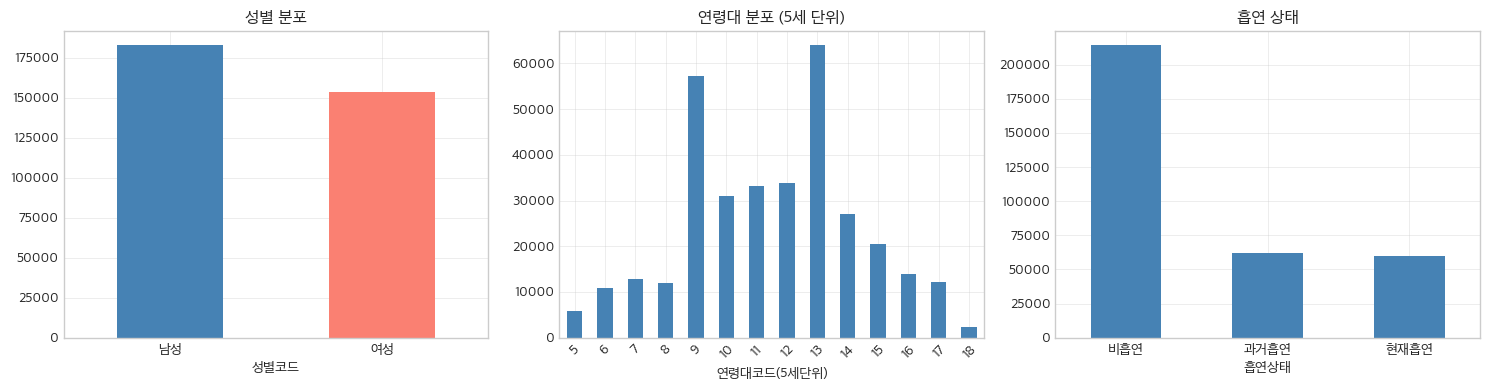

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 성별
gender_map = {1: '남성', 2: '여성'}
df['성별코드'].map(gender_map).value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('성별 분포')
axes[0].tick_params(axis='x', rotation=0)

# 연령대
df['연령대코드(5세단위)'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('연령대 분포 (5세 단위)')
axes[1].tick_params(axis='x', rotation=45)

# 흡연상태
smoke_map = {1.0: '비흡연', 2.0: '과거흡연', 3.0: '현재흡연'}
df['흡연상태'].map(smoke_map).value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('흡연 상태')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_인구통계분포.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 주요 수치 변수 분포

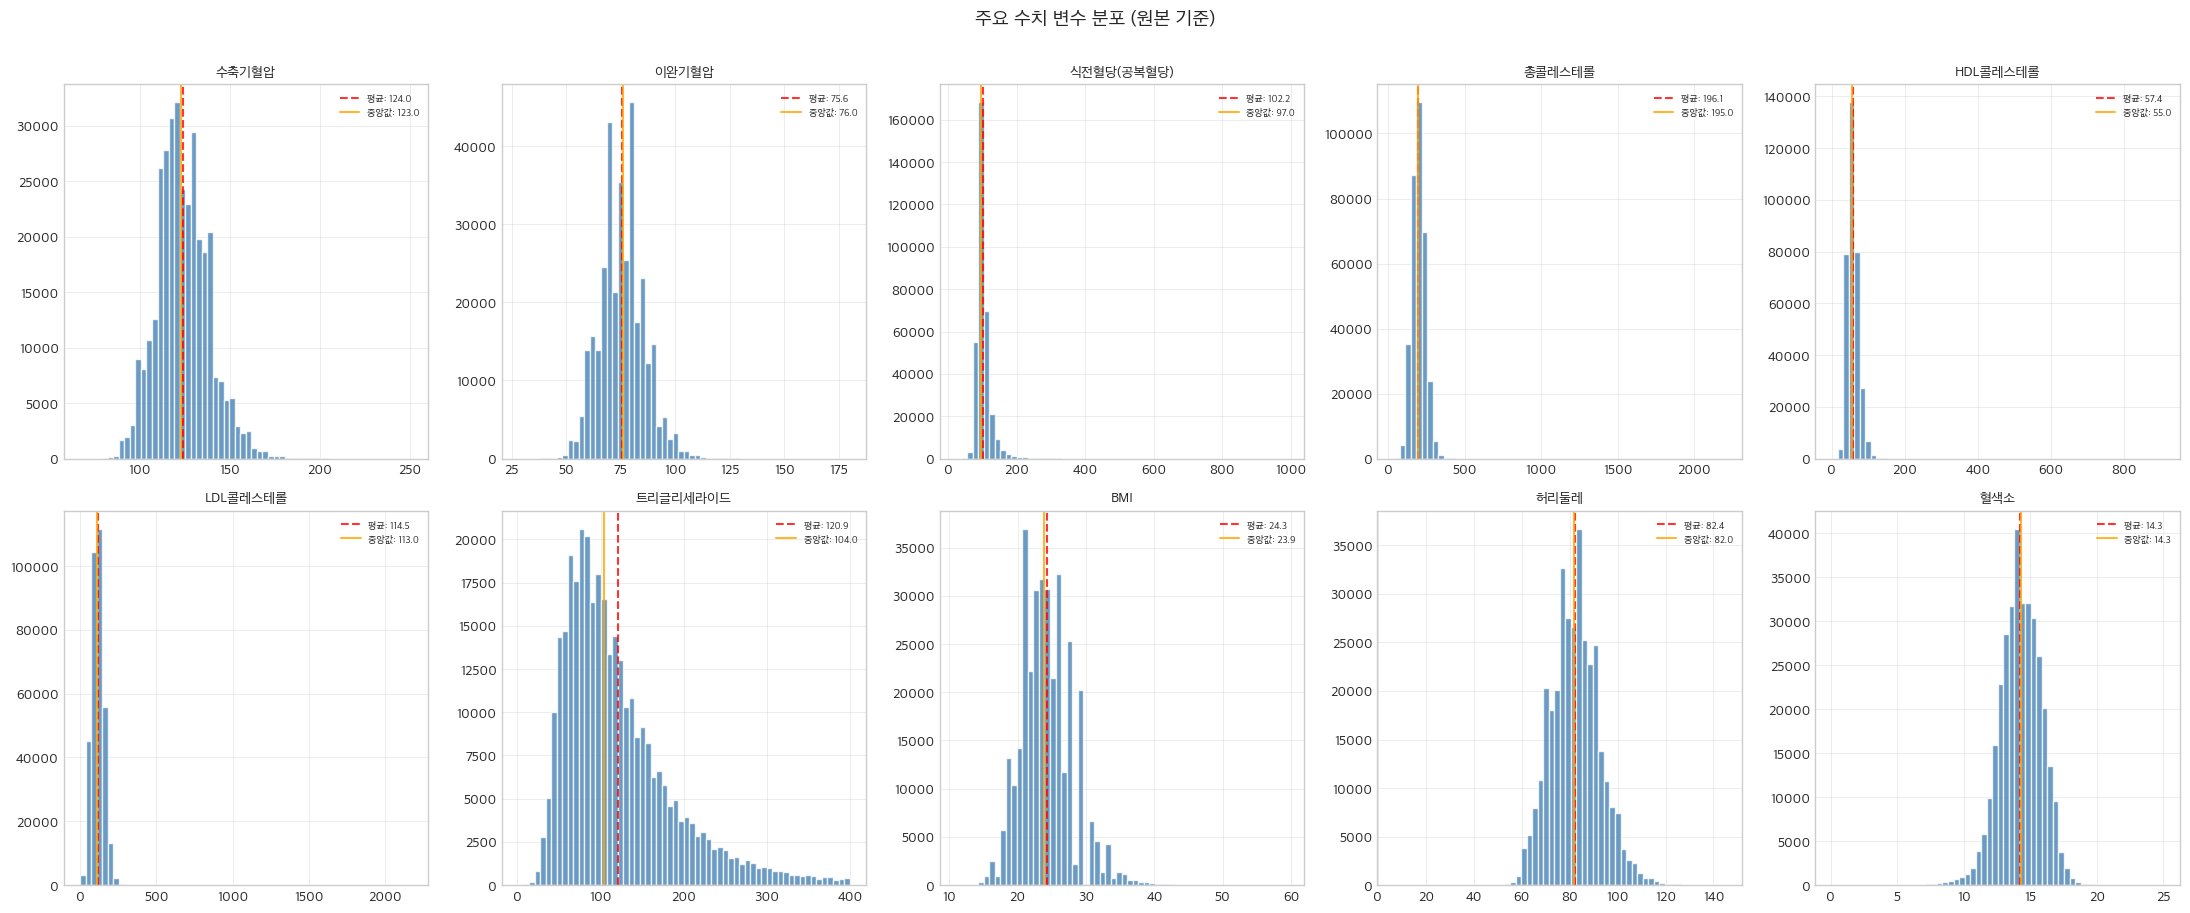

In [23]:
cont_cols = [
    '수축기혈압', '이완기혈압', '식전혈당(공복혈당)',
    '총콜레스테롤', 'HDL콜레스테롤', 'LDL콜레스테롤', '트리글리세라이드',
    'BMI', '허리둘레', '혈색소'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    data = df[col].dropna()
    mean_val   = data.mean()
    median_val = data.median()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(mean_val,   color='red',    linestyle='--', alpha=0.8, label=f'평균: {mean_val:.1f}')
    axes[i].axvline(median_val, color='orange', linestyle='-',  alpha=0.8, label=f'중앙값: {median_val:.1f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('주요 수치 변수 분포 (원본 기준)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_수치변수분포.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. 임상 기준 유병률

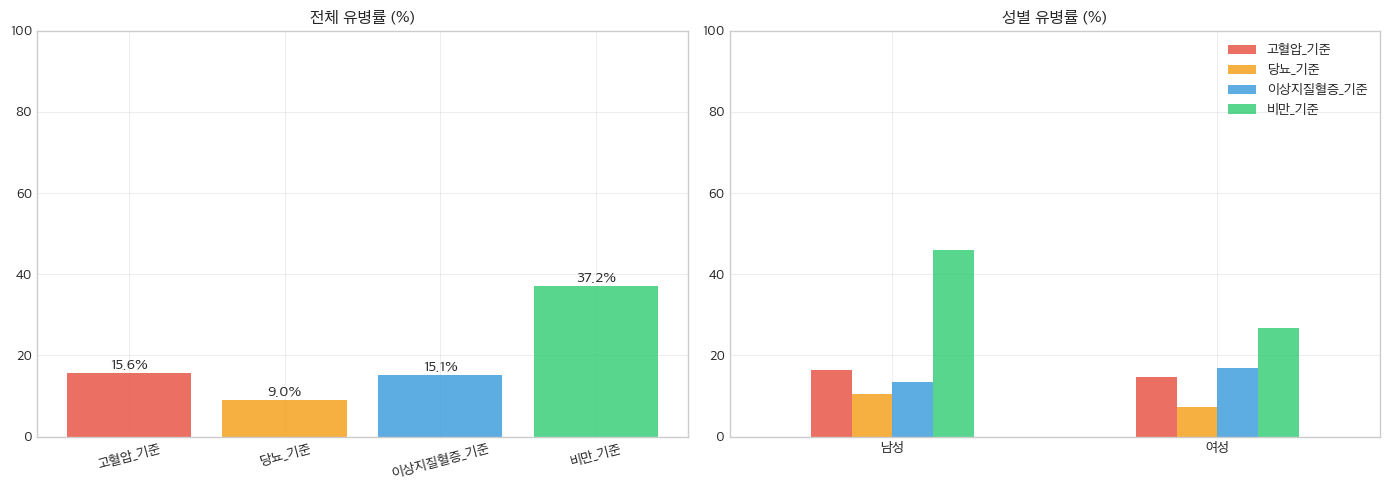

In [24]:
label_cols = ['고혈압_기준', '당뇨_기준', '이상지질혈증_기준', '비만_기준']
rates = df[label_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 유병률
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[0].bar(rates.index, rates.values, color=colors, alpha=0.8)
axes[0].set_title('전체 유병률 (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# 성별 유병률
gender_rate = df.groupby('성별코드')[label_cols].mean() * 100
gender_rate.index = ['남성', '여성']
gender_rate.plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('성별 유병률 (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_임상유병률_전체.png', dpi=150, bbox_inches='tight')
plt.show()

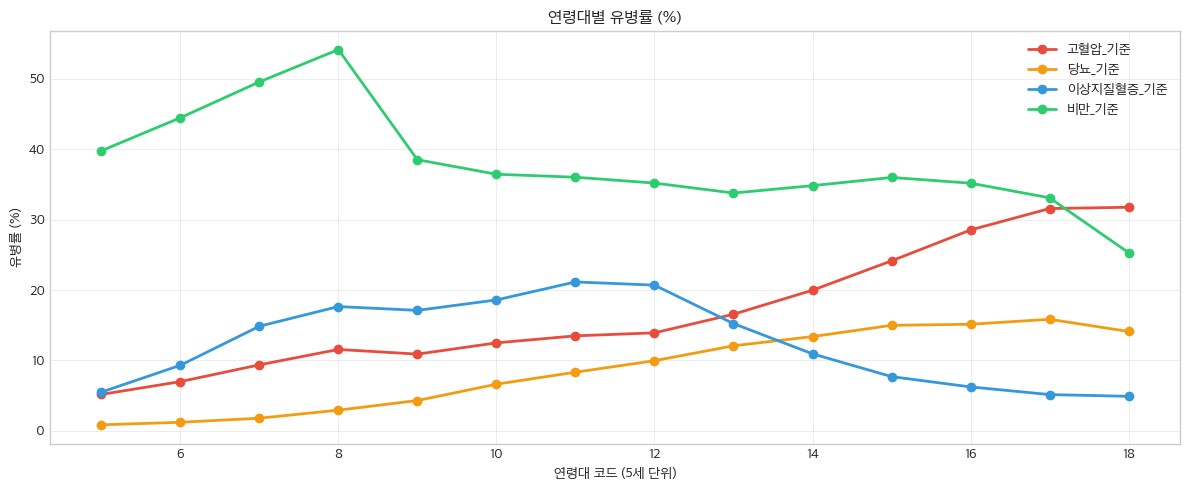

In [25]:
# 연령대별 유병률
age_rate = df.groupby('연령대코드(5세단위)')[label_cols].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(label_cols, colors):
    ax.plot(age_rate.index, age_rate[col], marker='o', label=col, color=color, linewidth=2)

ax.set_title('연령대별 유병률 (%)')
ax.set_xlabel('연령대 코드 (5세 단위)')
ax.set_ylabel('유병률 (%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_임상유병률_연령대.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 복합 질환 분포

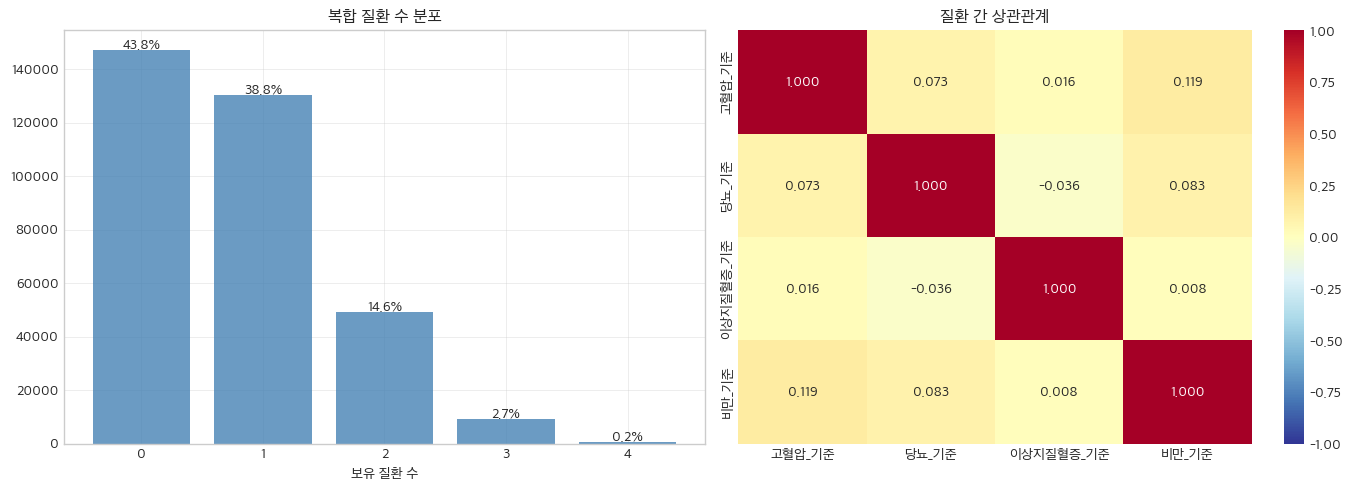


질환 수별 비율:
  0개: 147,193명 (43.8%)
  1개: 130,357명 (38.8%)
  2개: 49,163명 (14.6%)
  3개: 9,057명 (2.7%)
  4개: 619명 (0.2%)


In [26]:
df['질환수'] = df[label_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 질환 수 분포
cnt = df['질환수'].value_counts().sort_index()
axes[0].bar(cnt.index, cnt.values, color='steelblue', alpha=0.8)
axes[0].set_title('복합 질환 수 분포')
axes[0].set_xlabel('보유 질환 수')
for i, (idx, val) in enumerate(cnt.items()):
    axes[0].text(idx, val + 500, f'{val/len(df)*100:.1f}%', ha='center')

# 질환 조합 히트맵
combo = df[label_cols].corr()
sns.heatmap(combo, annot=True, fmt='.3f', cmap='RdYlBu_r',
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('질환 간 상관관계')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_복합질환분포.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n질환 수별 비율:')
for k, v in cnt.items():
    print(f'  {k}개: {v:,}명 ({v/len(df)*100:.1f}%)')

## 7. 주요 수치 변수 상관관계

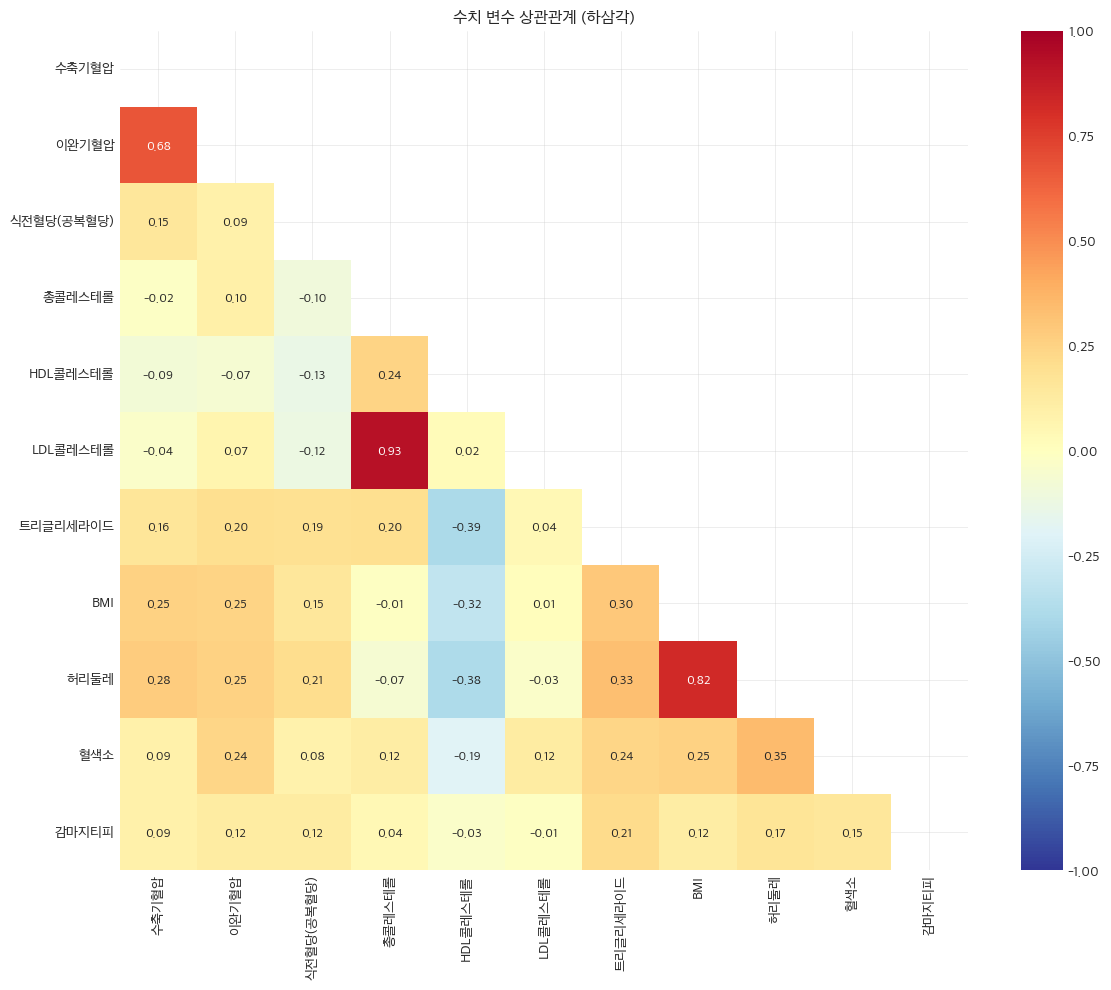

In [27]:
corr_cols = [
    '수축기혈압', '이완기혈압', '식전혈당(공복혈당)',
    '총콜레스테롤', 'HDL콜레스테롤', 'LDL콜레스테롤', '트리글리세라이드',
    'BMI', '허리둘레', '혈색소', '감마지티피'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, vmin=-1, vmax=1, annot_kws={'size': 9})
ax.set_title('수치 변수 상관관계 (하삼각)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_상관관계히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 이상치 확인

In [28]:
# 임상 기준 초과 이상치 수
clinical_bounds = {
    '수축기혈압':         (50,   300),
    '이완기혈압':         (20,   200),
    '식전혈당(공복혈당)': (30,  1000),
    '총콜레스테롤':       (50,  1000),
    '트리글리세라이드':   (10,  6000),
    'HDL콜레스테롤':      (10,   200),
    'LDL콜레스테롤':      (10,  1000),
    '혈색소':             (3,    25),
    '혈청크레아티닌':     (0.1,  50),
    '혈청지오티(AST)':   (5,  5000),
    '혈청지피티(ALT)':   (5,  5000),
    '감마지티피':         (1,  5000),
    '허리둘레':           (40,   200),
}

print('임상 기준 이상치 현황:')
print(f'{"변수":<25} {"하한":<8} {"상한":<8} {"이상치수":<10} {"비율"}')
print('-' * 65)
for col, (lower, upper) in clinical_bounds.items():
    if col not in df.columns:
        continue
    cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<25} {lower:<8} {upper:<8} {cnt:<10} {cnt/len(df)*100:.3f}%')

임상 기준 이상치 현황:
변수                        하한       상한       이상치수       비율
-----------------------------------------------------------------
수축기혈압                     50       300      0          0.000%
이완기혈압                     20       200      0          0.000%
식전혈당(공복혈당)                30       1000     2          0.001%
총콜레스테롤                    50       1000     7          0.002%
트리글리세라이드                  10       6000     46         0.014%
HDL콜레스테롤                  10       200      36         0.011%
LDL콜레스테롤                  10       1000     128        0.038%
혈색소                       3        25       4          0.001%
혈청크레아티닌                   0.1      50       2          0.001%
혈청지오티(AST)                5        5000     11         0.003%
혈청지피티(ALT)                5        5000     214        0.064%
감마지티피                     1        5000     2          0.001%
허리둘레                      40       200      1          0.000%


## 9. 성별 × 연령대 주요 수치 분포

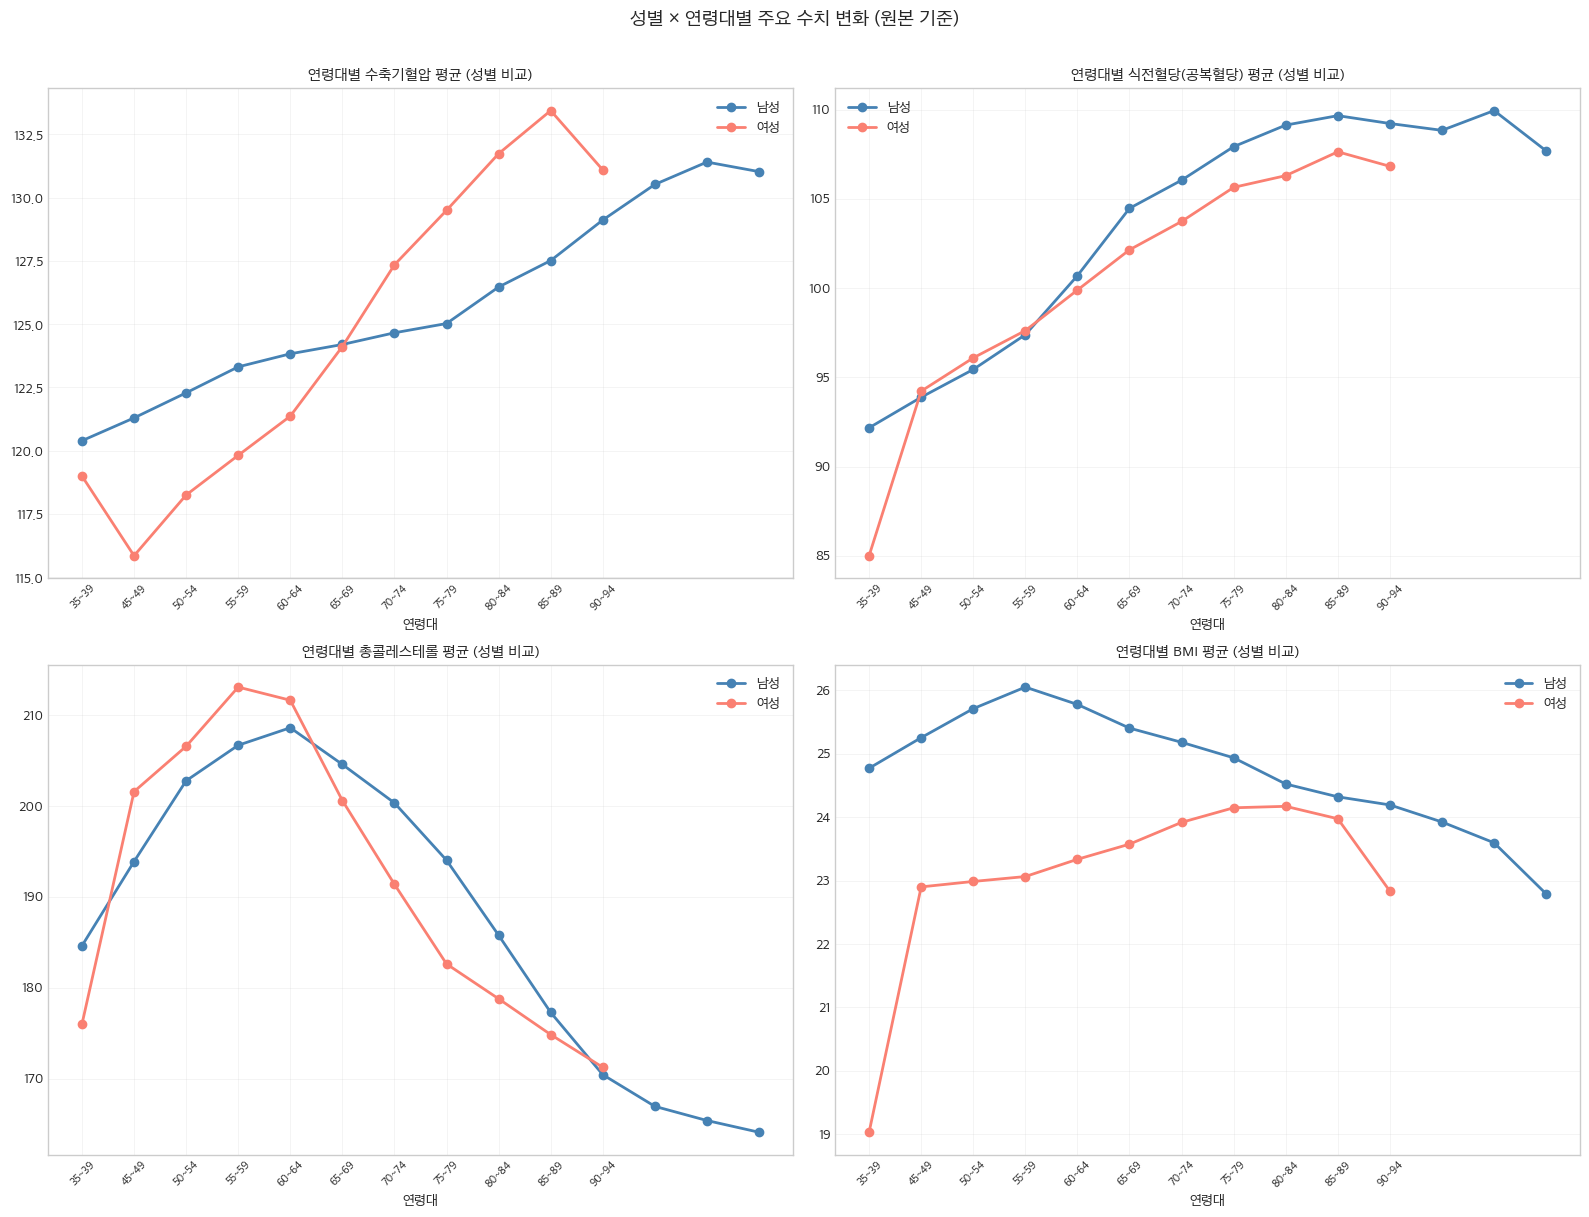

In [29]:
key_cols = ['수축기혈압', '식전혈당(공복혈당)', '총콜레스테롤', 'BMI']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    for sex_code, color, label in [(1, 'steelblue', '남성'), (2, 'salmon', '여성')]:
        grp = df[df['성별코드'] == sex_code].groupby('연령대코드(5세단위)')[col].mean()
        age_labels = [f'{int(k)*5}~{int(k)*5+4}' for k in grp.index]
        axes[i].plot(range(len(grp)), grp.values, marker='o',
                     color=color, label=label, linewidth=2)
        axes[i].set_xticks(range(len(grp)))
        axes[i].set_xticklabels(age_labels, rotation=45, fontsize=8)
    axes[i].set_title(f'연령대별 {col} 평균 (성별 비교)', fontsize=11)
    axes[i].set_xlabel('연령대')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('성별 × 연령대별 주요 수치 변화 (원본 기준)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_성별연령대수치변화.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. 클러스터링 전 변수 분포 요약

In [30]:
# 클러스터링 사용 변수 (트리글리세라이드 제거 — drop-one-out 노이즈 변수 +0.0124)
cont_use = [
    '신장(5cm단위)', '체중(5kg단위)', '허리둘레', 'BMI',
    '수축기혈압', '이완기혈압',
    '식전혈당(공복혈당)',
    '총콜레스테롤', 'HDL콜레스테롤', 'LDL콜레스테롤',
    '혈색소', '혈청크레아티닌',
    '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피'
]
cat_use = ['성별코드', '연령대코드(5세단위)', '흡연상태', '음주여부', '요단백']

print(f'연속형 피처 수: {len(cont_use)}')
print(f'범주형 피처 수: {len(cat_use)}')
print(f'총 피처 수: {len(cont_use) + len(cat_use)}')

# CLINICAL_BOUNDS 제거 후 dropna 유효 샘플 수
df_clean = df.copy()
for col, (lo, hi) in CLINICAL_BOUNDS.items():
    if col in df_clean.columns:
        df_clean.loc[(df_clean[col] < lo) | (df_clean[col] > hi), col] = np.nan

df_valid = df_clean.dropna(subset=cont_use + cat_use)
print(f'\n원본 샘플 수: {len(df):,}')
print(f'CLINICAL_BOUNDS 제거 후 dropna 유효 샘플 수: {len(df_valid):,}')
print(f'제거 비율: {(1 - len(df_valid)/len(df))*100:.2f}%')
print()
print('연속형 변수 기초통계 (유효 샘플 기준):')
df_valid[cont_use].describe().round(2)


연속형 피처 수: 15
범주형 피처 수: 5
총 피처 수: 20

원본 샘플 수: 336,389
CLINICAL_BOUNDS 제거 후 dropna 유효 샘플 수: 331,642
제거 비율: 1.41%

연속형 변수 기초통계 (유효 샘플 기준):


,신장(5cm단위),체중(5kg단위),허리둘레,BMI,수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,HDL콜레스테롤,LDL콜레스테롤,혈색소,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피
count,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00,331642.00
mean,162.33,64.44,82.34,24.30,124.00,75.61,102.07,196.15,57.33,114.60,14.25,0.86,27.14,26.45,32.85
std,9.67,13.63,10.23,3.81,14.54,10.21,22.68,42.49,14.80,38.66,1.54,0.32,12.59,17.92,31.19
min,130.00,30.00,43.00,11.02,72.00,31.00,50.00,60.00,10.00,10.00,5.00,0.30,5.00,5.00,1.00
25%,155.00,55.00,75.00,21.48,114.00,69.00,90.00,166.00,47.00,87.00,13.20,0.70,20.00,16.00,16.00
50%,160.00,65.00,82.00,23.88,123.00,76.00,97.00,195.00,55.00,113.00,14.30,0.80,24.00,22.00,23.00
75%,170.00,75.00,89.00,26.23,133.00,82.00,107.00,224.00,66.00,140.00,15.30,1.00,30.00,31.00,37.00
max,195.00,135.00,145.00,59.45,240.00,148.00,494.00,484.00,150.00,380.00,21.00,14.80,200.00,200.00,300.00


## 11. 변수별 결측치 패턴

In [31]:
# 결측치 현황 수치 출력
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'결측수': miss, '결측률(%)': miss_pct})
print(miss_df.to_string())
print(f'\n결측 있는 변수 수: {len(miss)}개')


        결측수  결측률(%)
요단백    1929    0.57
흡연상태     47    0.01
허리둘레     28    0.01
음주여부     19    0.01
수축기혈압     4    0.00
혈색소       4    0.00
이완기혈압     3    0.00

결측 있는 변수 수: 7개


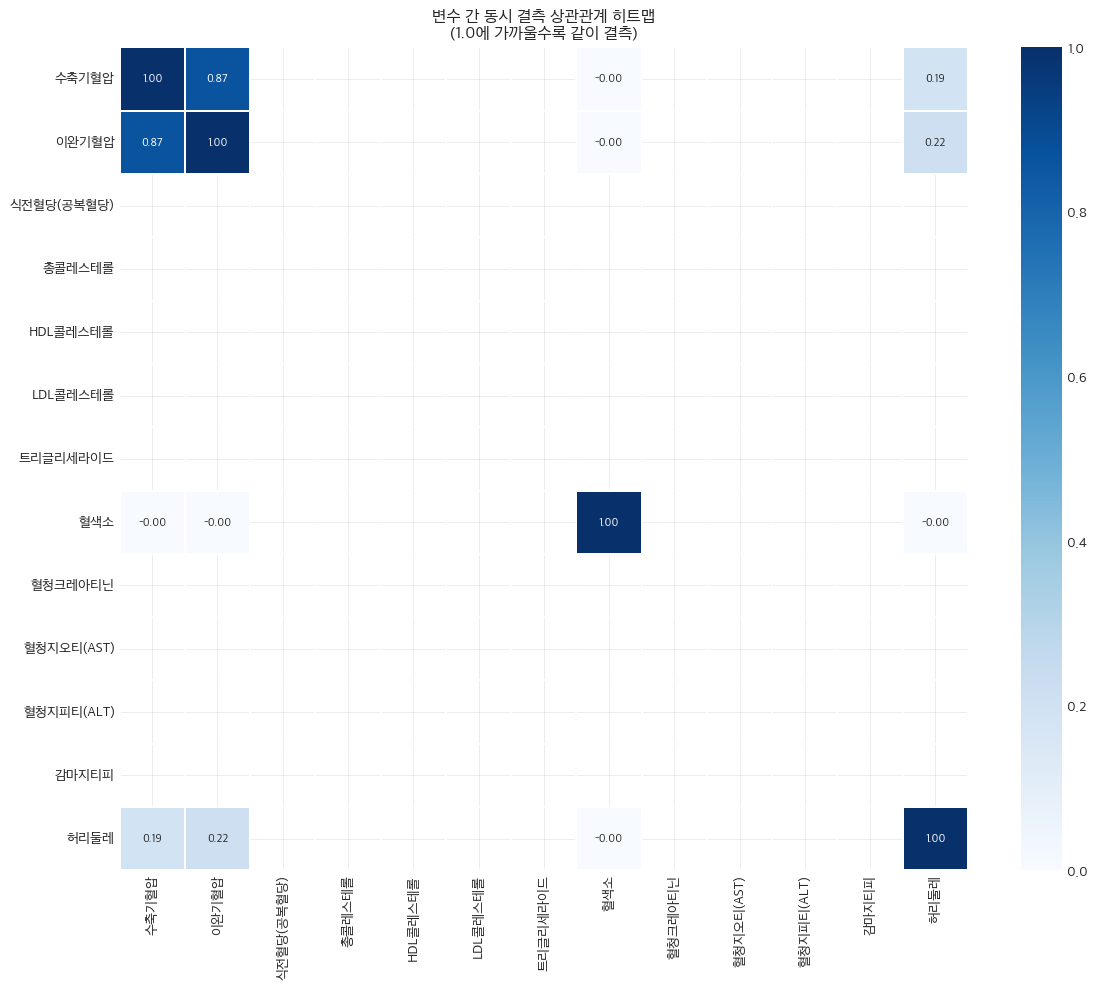

In [32]:
# 주요 변수 결측 패턴 히트맵 (동시 결측 여부)
check_cols = [
    '수축기혈압', '이완기혈압', '식전혈당(공복혈당)',
    '총콜레스테롤', 'HDL콜레스테롤', 'LDL콜레스테롤', '트리글리세라이드',
    '혈색소', '혈청크레아티닌',
    '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '허리둘레'
]
check_cols = [c for c in check_cols if c in df.columns]

miss_matrix = df[check_cols].isnull().astype(int)
miss_corr = miss_matrix.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax, annot_kws={'size': 8}, linewidths=0.3)
ax.set_title('변수 간 동시 결측 상관관계 히트맵\n(1.0에 가까울수록 같이 결측)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_결측패턴히트맵.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. 주요 수치 변수 Boxplot (성별 비교)

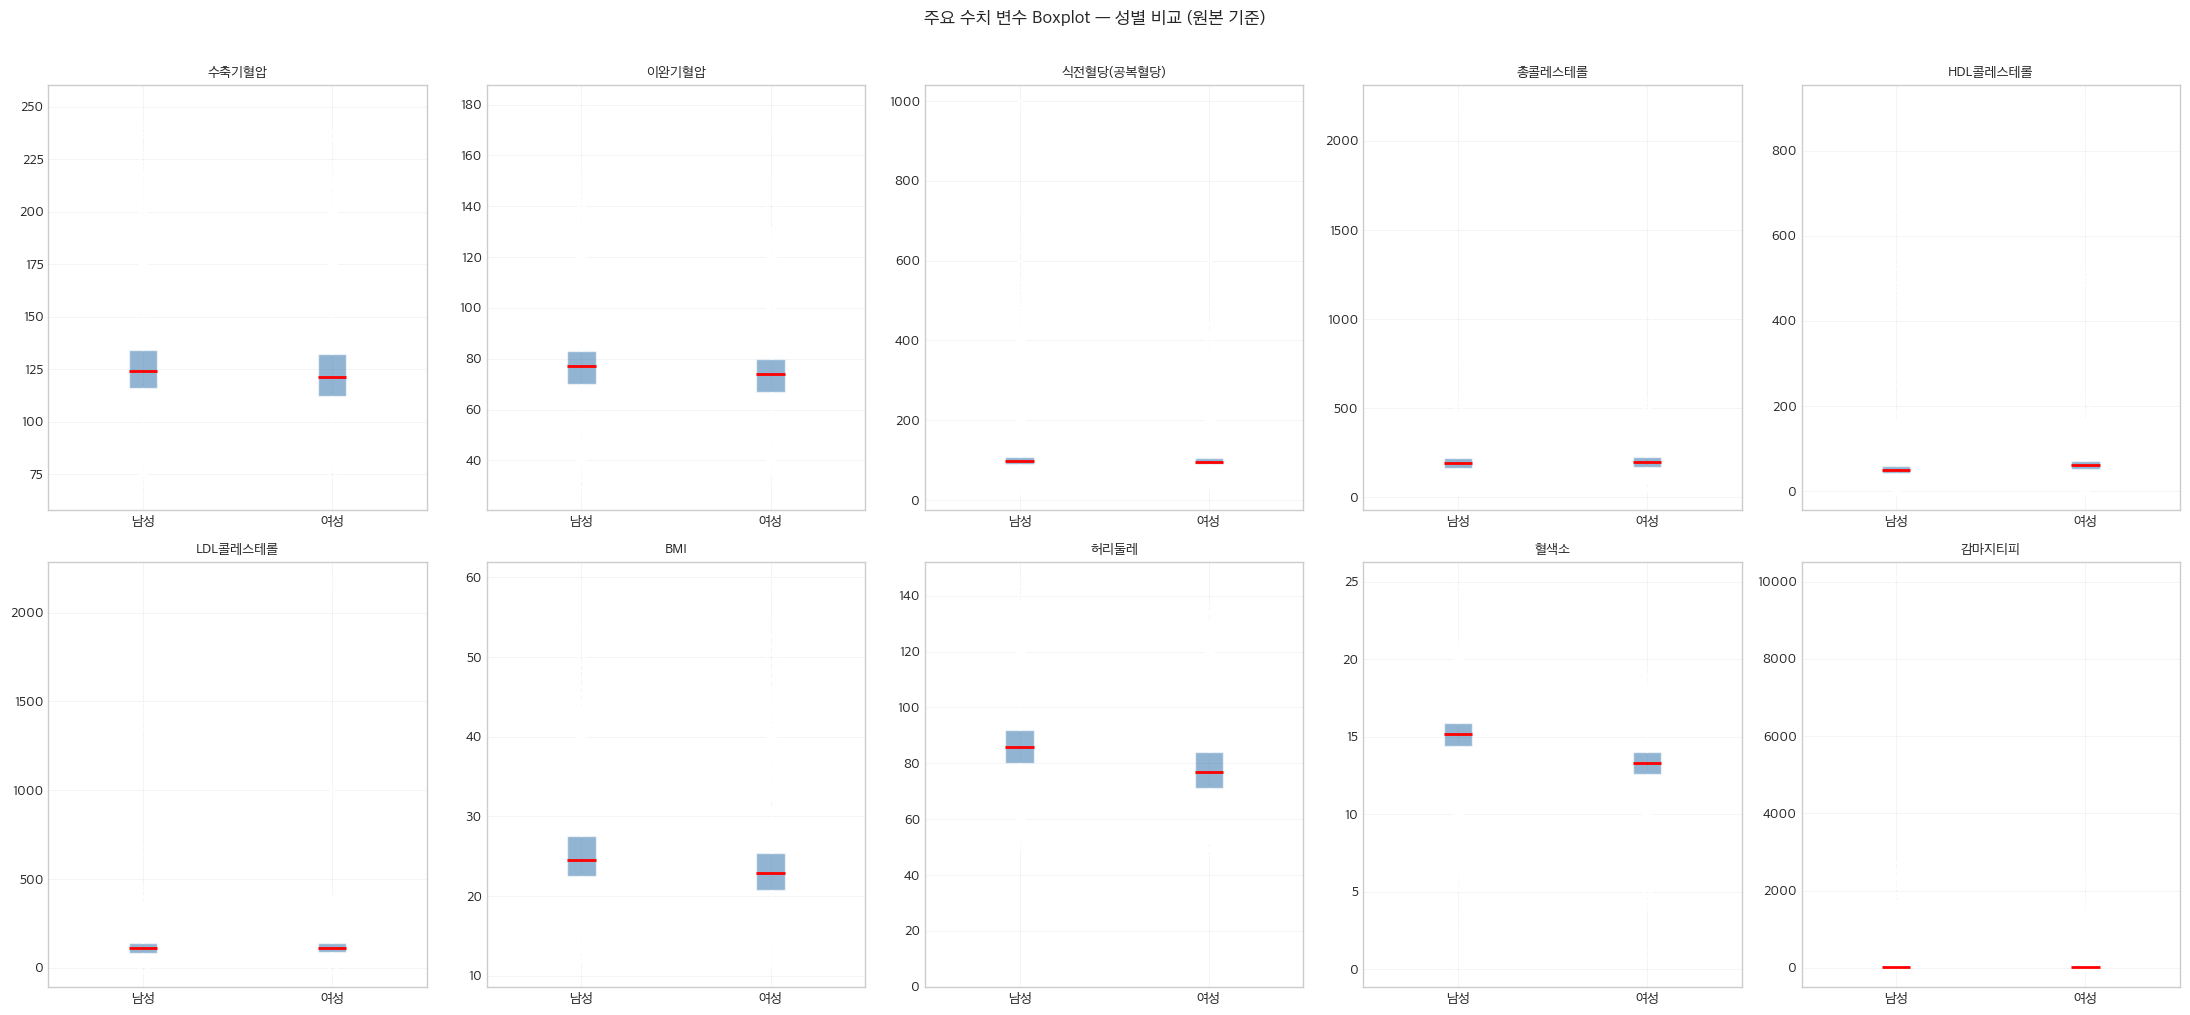

In [33]:
box_cols = [
    '수축기혈압', '이완기혈압', '식전혈당(공복혈당)',
    '총콜레스테롤', 'HDL콜레스테롤', 'LDL콜레스테롤',
    'BMI', '허리둘레', '혈색소', '감마지티피'
]

df['성별'] = df['성별코드'].map({1: '남성', 2: '여성'})

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    data_m = df[df['성별코드']==1][col].dropna()
    data_f = df[df['성별코드']==2][col].dropna()
    axes[i].boxplot([data_m, data_f], labels=['남성', '여성'],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('주요 수치 변수 Boxplot — 성별 비교 (원본 기준)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_boxplot_성별비교.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. 범주형 변수 분포 (음주여부 / 요단백)

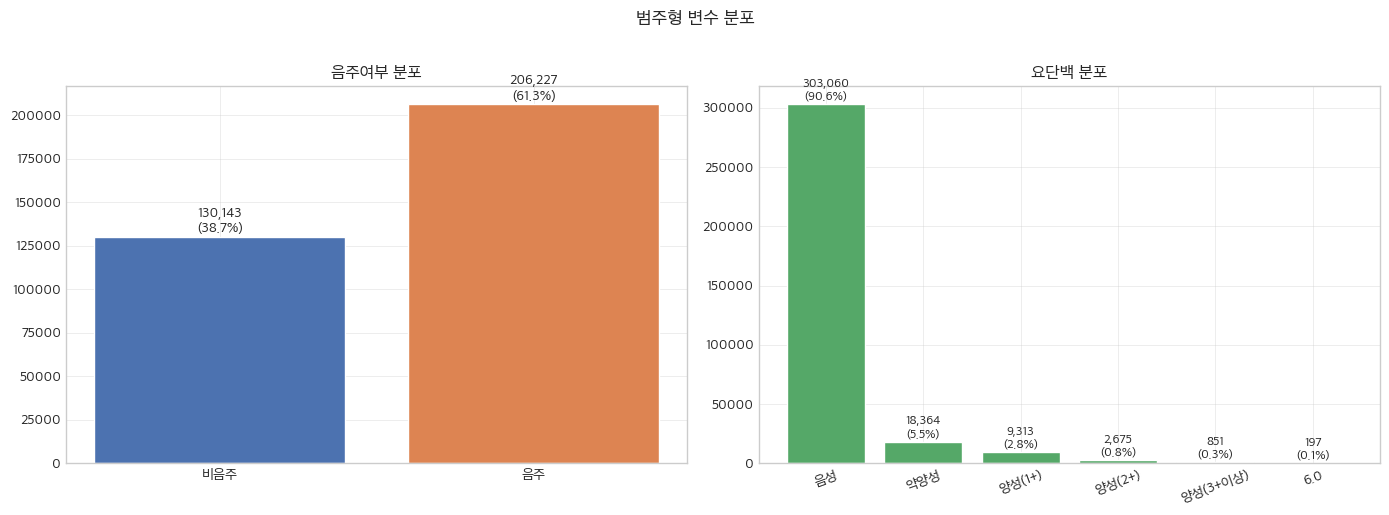

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 음주여부
drink_map = {0: '비음주', 1: '음주'}
drink_vc = df['음주여부'].value_counts().sort_index()
axes[0].bar([drink_map.get(k, str(k)) for k in drink_vc.index],
            drink_vc.values, color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('음주여부 분포', fontsize=12)
for i, (v, p) in enumerate(zip(drink_vc.values, drink_vc/drink_vc.sum()*100)):
    axes[0].text(i, v + drink_vc.max()*0.01, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)

# 요단백
prot_map = {1: '음성', 2: '약양성', 3: '양성(1+)', 4: '양성(2+)', 5: '양성(3+이상)'}
prot_vc = df['요단백'].value_counts().sort_index()
axes[1].bar([prot_map.get(k, str(k)) for k in prot_vc.index],
            prot_vc.values, color='#55A868', edgecolor='white')
axes[1].set_title('요단백 분포', fontsize=12)
axes[1].tick_params(axis='x', rotation=20)
for i, (v, p) in enumerate(zip(prot_vc.values, prot_vc/prot_vc.sum()*100)):
    axes[1].text(i, v + prot_vc.max()*0.01, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9)

plt.suptitle('범주형 변수 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_범주형변수분포.png', dpi=150, bbox_inches='tight')
plt.show()
